# 02 Groundwater Monitoring

**Series:** Tribal Water Monitoring  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC
**Primary Focus:** Pine Ridge (Oglala Lakota), Rosebud (Sicangu Lakota)  
**Collective:** Oceti Sakowin  
**Data Sources:** USGS NWIS (public), Tribal-collected well data (if available)


## Why Groundwater First
On Pine Ridge and Rosebud, groundwater is the primary water source. 
Surface streams are seasonal and often dry outside spring runoff. 
The communities, livestock operations, and bison herds that sustain life 
on these lands depend on what comes out of the ground.

The principal aquifer beneath Pine Ridge and Rosebud is the Arikaree
aquifer (a formation of the Ogallala/High Plains Aquifer system). It is a finite
resource: recharge is slow (decades to centuries), extraction is immediate.
Climate stress such as increased evaporation, less snowpack recharge, and longer droughts
is reducing recharge while demand is stable or increasing.

## Data Approach
This notebook uses three complementary data sources:
**USGS monitoring locations and field measurements:** A sparse public
monitoring network around the study area. These sites can have long records,
but they are not a complete well inventory.

**Historical well inventories:** Carter and Heakin (2007) documents wells
and springs in Pine Ridge and Bennett County. Inventory wells must not be
presented as currently monitored wells or current water-level observations.

**Tribal-collected data:** Well level measurements from `data/raw/`.
If no file is present, the notebook degrades to USGS data only
and prompts the use of the Excel template in `data/templates/`.

## Research Questions
- What do long-term USGS well records near Pine Ridge and Rosebud show?
- Is there a declining trend in water levels?
- Where are the monitoring dead zones (areas with no well data at all)?
- What does Tribal-collected well data add that USGS cannot see?

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import requests
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    OCETI_SAKOWIN_BBOX, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    PRIMARY_NATIONS, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import (
    load_tribal_boundaries,
    load_usgs_groundwater_sites,
    load_usgs_groundwater_levels,
    load_carter_2007_inventory,
    load_tribal_groundwater,
)
from src.indicators import (
    compute_groundwater_trend,
    classify_groundwater_status,
    groundwater_percentile_rank,
    theilsen_trend,
)
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# print(f"Repo root : {REPO_ROOT}")
print(f"Analysis  : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("Imports complete.")

Analysis  : 2026-08-18 14:16
Imports complete.


In [2]:
# Print data sovereignty statement at the top of every notebook
print_data_acknowledgment(
    source_keys=["census_aiannh", "usgs_nwis_groundwater", "tribal_groundwater"]
)


TRIBAL WATER MONITORING DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands, waters, and communities
of the Oceti Sakowin (the seven council fires of the Lakota, Dakota, and
Nakota peoples). This data is governed by the following frameworks:

OCAP®  : The Oceti Sakowin and all Tribal Nations have the right to
  Ownership, Control, Access, and Possession of data about their lands
  and communities. Federal monitoring data covering Tribal territories
  does not transfer that authority to federal agencies or researchers.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations 

## Load Boundaries and USGS Well Sites

In [3]:
# Load from notebook 01 output if available
boundaries_path = OUTPUTS_DIR/"oceti_sakowin_boundaries.geojson"
if boundaries_path.exists():
    oceti_sakowin = gpd.read_file(boundaries_path)
    print(f"Boundaries loaded from notebook 01: {len(oceti_sakowin)} Nations")
else:
    oceti_sakowin = load_tribal_boundaries()
    print(f"Boundaries downloaded: {len(oceti_sakowin)} Nations")

primary = oceti_sakowin[oceti_sakowin["common_name"].isin(PRIMARY_NATIONS)]

Boundaries loaded from notebook 01: 8 Nations


In [4]:
# Discover USGS groundwater monitoring wells in the study area.
# This is deliberately separate from the historical Carter inventory.
gw_sites = load_usgs_groundwater_sites(bbox=OCETI_SAKOWIN_BBOX)
carter_inventory = load_carter_2007_inventory()

print(f"USGS groundwater sites found: {len(gw_sites)}")
print(f"Carter 2007 inventory features: {len(carter_inventory)} (not current monitoring)")
if not gw_sites.empty and "site_no" in gw_sites.columns:
    print("\nSite IDs (use these in config.yaml > usgs_groundwater_sites):")
    cols = [c for c in ["site_no", "station_nm", "dec_lat_va",
                        "dec_long_va", "begin_date", "end_date"]
            if c in gw_sites.columns]
    print(gw_sites[cols].head(15).to_string(index=False))

USGS groundwater sites found: 89427
Carter 2007 inventory features: 1197 (not current monitoring)

Site IDs (use these in config.yaml > usgs_groundwater_sites):
        site_no     station_nm  dec_lat_va  dec_long_va
413631104060401 29-060-17dcc01   42.479965  -104.115775
413800104290301 30-064-12abd01   42.592467  -104.484676
413910104232701 30-063-35dcc01   42.523578  -104.390228
413923104041701 30-060-34cbc02   42.526909  -104.067718
413948104034501 30-060-34bad01   42.534131  -104.060218
413957104390001 30-063-35bbb01   42.536355  -104.399951
414206104042001 30-060-15cbb02   42.572743  -104.067717
414212104272501 30-063-17bcd01   42.574134  -104.455508
414730104070201 31-060-18acd01   42.662466  -104.110218
415800101561201     41N39W35CA   43.481944  -101.933483
420200104120001 30-061-33acc01   42.531076  -104.194111
420201104100101 30-061-35abb01   42.536632  -104.155220
420201104110101 30-061-34add01   42.531076  -104.167443
420201104120101 30-061-33bca01   42.532743  -104.201611

In [5]:
# Filter to wells with long records that are the most useful for trend analysis
# Prioritize wells nearest to Pine Ridge and Rosebud centroids

if not gw_sites.empty:
    primary_proj  = primary.to_crs(CRS_PROJECTED)
    sites_proj    = gw_sites.to_crs(CRS_PROJECTED)

    candidate_sites = []
    for _, nation in primary_proj.iterrows():
        centroid = nation.geometry.centroid
        dists    = sites_proj.geometry.distance(centroid) / 1000
        nearby   = gw_sites[(dists <= 100).values].copy()
        nearby["dist_km"]    = dists[(dists <= 100).values].round(1).values
        nearby["nation"]     = nation["common_name"]
        candidate_sites.append(nearby)

    candidates = pd.concat(candidate_sites, ignore_index=True).drop_duplicates(
        subset="site_no"
    )

    # Check record length if begin_date available
    if "begin_date" in candidates.columns:
        candidates["begin_date"] = pd.to_datetime(
            candidates["begin_date"], errors="coerce"
        )
        candidates["record_years"] = (
            (pd.Timestamp.now() - candidates["begin_date"]).dt.days / 365
        ).round(1)
        long_record = candidates[candidates["record_years"] >= 10].copy()
        print(f"Wells within 100 km of primary Nations: {len(candidates)}")
        print(f"Wells with ≥ 10 years of record: {len(long_record)}")
    else:
        long_record = candidates.copy()
        print(f"Candidate wells: {len(candidates):,}")
        print("Next cell filters these by recent USGS groundwater-level records.")
else:
    long_record = pd.DataFrame()
    print("No USGS wells found. This is a monitoring gap finding.")

Candidate wells: 8,472
Next cell filters these by recent USGS groundwater-level records.


In [6]:
# Select candidates with recent USGS depth-to-water field measurements.
# Metadata is queried once for the area, then joined to the nearby candidates.
FIELD_METADATA_URL = (
    "https://api.waterdata.usgs.gov/ogcapi/v0/collections/"
    "field-measurements-metadata/items"
)
RECENT_SINCE = "2020-01-01T00:00:00Z"

def fetch_ogc_features(url, params):
    features = []
    while url:
        response = requests.get(url, params=params, timeout=120)
        response.raise_for_status()
        payload = response.json()
        features.extend(payload.get("features", []))
        url = next((link.get("href") for link in payload.get("links", [])
                    if link.get("rel") == "next"), None)
        params = {}  # next link already includes its query parameters
    return features

recent_wells = pd.DataFrame()
if not long_record.empty:
    metadata_features = fetch_ogc_features(
        FIELD_METADATA_URL,
        {
            "bbox": ",".join(map(str, OCETI_SAKOWIN_BBOX)),
            "parameter_code": "72019",  # depth to water below land surface
            "end": f"{RECENT_SINCE}/..",
            "limit": 1000,
            "f": "json",
        },
    )
    field_metadata = pd.DataFrame([f.get("properties", {}) for f in metadata_features])
    if not field_metadata.empty:
        field_metadata["end"] = pd.to_datetime(field_metadata["end"], errors="coerce", utc=True)
        recent_wells = (
            long_record.merge(
                field_metadata[["monitoring_location_id", "begin", "end", "parameter_name"]],
                on="monitoring_location_id", how="inner",
            )
            .sort_values(["end", "dist_km"], ascending=[False, True])
            .drop_duplicates(subset="site_no")
            .reset_index(drop=True)
        )

if recent_wells.empty:
    print(f"No nearby USGS depth-to-water records since {RECENT_SINCE[:4]}.")
else:
    print(f"Recent groundwater-level candidates: {len(recent_wells):,}")
    print(recent_wells[["site_no", "station_nm", "end", "dist_km"]].head(10).to_string(index=False))
    long_record = recent_wells  # consumed by the time-series cell below


Recent groundwater-level candidates: 234
        site_no                                        station_nm                       end  dist_km
425125100312701                  33N 27W05CA 01 Val Site1 Shallow 2026-07-08 20:08:00+00:00     51.3
430415100451501    36N29W29ABDD RST GW WELL R-7 NR ST.FRANCIS, SD 2026-06-23 14:30:00+00:00     28.0
430258100471401 36N30W36DDDA (RST GW WELL RB-8 NR ST.FRANCIS, SD) 2026-06-23 14:10:00+00:00     31.4
430154100411801   35N29W 2DDDD RST GW WELL M-10 NR OLSONVILLE, SD 2026-06-23 13:35:00+00:00     31.0
430314100372001   36N28W33BDDB (RST well R-19 near Olsonville SD) 2026-06-23 12:35:00+00:00     28.4
430153100531002   35N30W 6DDD2 RST GW WELL M-5 NR ST. FRANCIS, SD 2026-06-22 23:00:00+00:00     36.7
430726101033501    36N32W2BAA RST GW WELL S-2 NR SPRING CREEK, SD 2026-06-22 22:25:00+00:00     87.0
430712100421301     36N29W 2CDCC RST GW WELL M-12 NR LAKEVIEW, SD 2026-06-22 21:15:00+00:00     21.7
431116100422001   37N29W12CCD RST GW WELL RB-14 NR

## Fetch USGS Groundwater Level Time Series

In [7]:
# Fetch water level records for up to 5 wells
MAX_WELLS   = 5
gwl_parts   = []
gwl_failed  = []

wells_to_fetch = long_record.head(MAX_WELLS) if not long_record.empty else pd.DataFrame()

for _, site in wells_to_fetch.iterrows():
    site_no   = site["site_no"]
    site_name = site.get("station_nm", site_no)
    try:
        df = load_usgs_groundwater_levels(site_no=site_no)
        if df.empty:
            print(f"  {site_name}: no data")
            continue
        df["site_name"] = str(site_name)[:50]
        df["nation"]    = site.get("nation", "Unknown")
        gwl_parts.append(df)
        print(f"  {site_name}: {len(df)} measurements "
              f"({df['date'].min().year}–{df['date'].max().year})")
    except Exception as e:
        gwl_failed.append(site_no)
        print(f"  {site_name}: failed — {e}")

if gwl_parts:
    gwl_df = pd.concat(gwl_parts, ignore_index=True)
    gwl_df["year"]  = gwl_df["date"].dt.year
    gwl_df["month"] = gwl_df["date"].dt.month
    print(f"\nTotal USGS groundwater records: {len(gwl_df):,}")
else:
    gwl_df = pd.DataFrame()
    print("\nNo USGS groundwater level data available.")
    print("Coverage gap near Tribal lands is itself a critical finding.")

  33N 27W05CA 01 Val Site1 Shallow: 2 measurements (2026–2026)
  36N29W29ABDD RST GW WELL R-7 NR ST.FRANCIS, SD: 76 measurements (2012–2026)
  36N30W36DDDA (RST GW WELL RB-8 NR ST.FRANCIS, SD): 251 measurements (1984–2026)
  35N29W 2DDDD RST GW WELL M-10 NR OLSONVILLE, SD: 256 measurements (1984–2026)
  36N28W33BDDB (RST well R-19 near Olsonville SD): 77 measurements (2012–2026)

Total USGS groundwater records: 662


## Load Tribal-Collected Well Data

In [8]:
# Load from data/raw/ stays local, never committed
# Returns empty DataFrame if no file exists, with helpful prompt

tribal_gw = load_tribal_groundwater()

if tribal_gw.empty:
    print("No Tribal groundwater data loaded.")
    print()
    print("To add field measurements:")
    print("  1. Copy data/templates/groundwater_template.xlsx")
    print("  2. Fill in well_id, date, water_level_ft")
    print("  3. Save as data/raw/groundwater.xlsx")
    print("  4. Re-run this notebook")
    print()
    print("Required columns: well_id, date, water_level_ft")
    print("See docs/data_intake_guide.md for field staff instructions")
else:
    print(f"Tribal groundwater data: {len(tribal_gw):,} records")
    print(f"Wells: {tribal_gw['well_id'].nunique()}")
    print(f"Date range: {tribal_gw['date'].min().date()} to "
          f"{tribal_gw['date'].max().date()}")
    print(tribal_gw.head(4).to_string(index=False))

No Tribal groundwater data loaded.

To add field measurements:
  1. Copy data/templates/groundwater_template.xlsx
  2. Fill in well_id, date, water_level_ft
  3. Save as data/raw/groundwater.xlsx
  4. Re-run this notebook

Required columns: well_id, date, water_level_ft
See docs/data_intake_guide.md for field staff instructions


## Trend Analysis

In [9]:
# Trend analysis for USGS wells
trend_records = []

if not gwl_df.empty:
    for site_no, grp in gwl_df.groupby("site_no"):
        annual = grp.groupby("year")["water_level_ft"].median().reset_index()
        if len(annual) < 5:
            continue
        trend = theilsen_trend(
            values=annual["water_level_ft"].values,
            years=annual["year"].values,
        )
        trend["site_no"]   = site_no
        trend["site_name"] = grp["site_name"].iloc[0]
        trend["nation"]    = grp["nation"].iloc[0]
        trend["n_years"]   = len(annual)
        # Positive slope = depth increasing = water table falling
        trend["direction"] = "Declining" if trend["slope"] > 0 else "Rising/Stable"
        trend_records.append(trend)

if trend_records:
    trend_df = pd.DataFrame(trend_records)
    print("GROUNDWATER LEVEL TRENDS (Theil-Sen slope)")
    print("Positive slope = depth to water INCREASING = water table FALLING")
    print(
        trend_df[["site_name", "nation", "n_years",
                  "slope_per_decade", "direction", "p_value", "significant"]]
        .sort_values("slope_per_decade", ascending=False)
        .to_string(index=False)
    )
else:
    trend_df = pd.DataFrame()
    print("Insufficient USGS well data for trend analysis.")
    print("Tribal-collected well data (data/raw/) fills this gap.")

GROUNDWATER LEVEL TRENDS (Theil-Sen slope)
Positive slope = depth to water INCREASING = water table FALLING
                                        site_name                   nation  n_years  slope_per_decade     direction  p_value  significant
   36N29W29ABDD RST GW WELL R-7 NR ST.FRANCIS, SD Sicangu Lakota (Rosebud)       15           -0.0833 Rising/Stable     0.82        False
36N30W36DDDA (RST GW WELL RB-8 NR ST.FRANCIS, SD) Sicangu Lakota (Rosebud)       42           -0.8400 Rising/Stable     0.00         True
  35N29W 2DDDD RST GW WELL M-10 NR OLSONVILLE, SD Sicangu Lakota (Rosebud)       43           -0.9340 Rising/Stable     0.00         True
  36N28W33BDDB (RST well R-19 near Olsonville SD) Sicangu Lakota (Rosebud)       15           -0.9346 Rising/Stable     0.09        False


## Visualizations

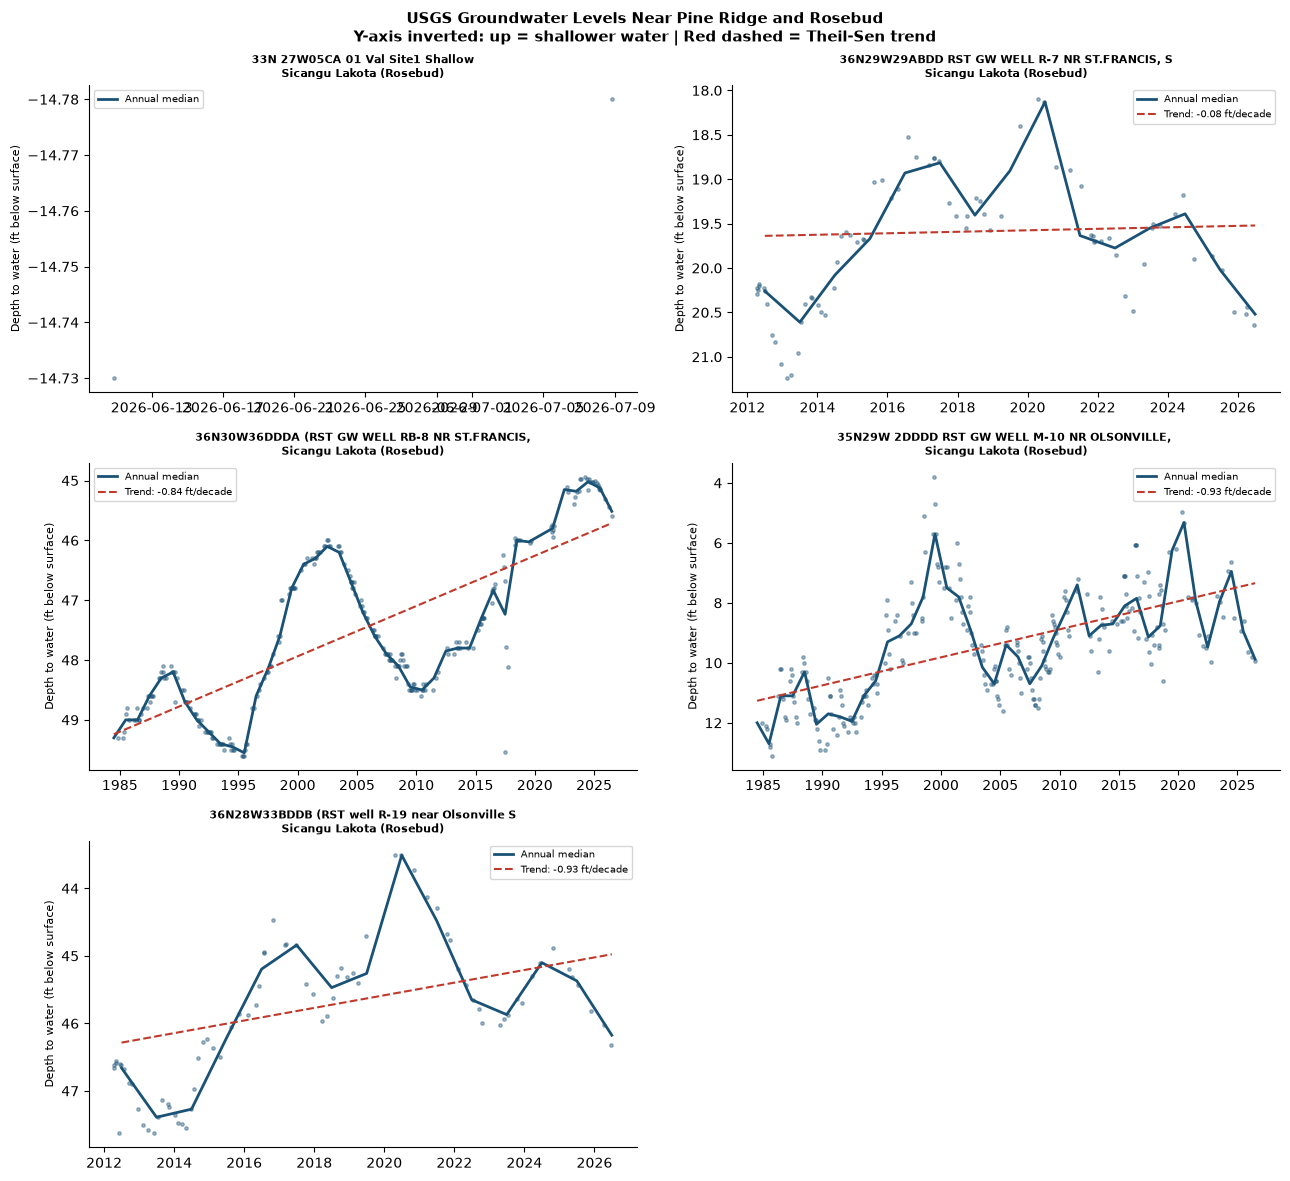

In [16]:
# USGS well time series
if not gwl_df.empty:
    sites = gwl_df["site_no"].unique()
    n     = len(sites)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4))
    axes = np.array(axes).flatten()

    for i, site_no in enumerate(sites):
        ax   = axes[i]
        grp  = gwl_df[gwl_df["site_no"] == site_no].sort_values("date")
        name = grp["site_name"].iloc[0]
        nation = grp["nation"].iloc[0]

        ax.scatter(grp["date"], grp["water_level_ft"],
                   color="#1A5276", s=6, alpha=0.4)

        # Annual median
        annual = grp.groupby("year")["water_level_ft"].median().reset_index()
        annual["date_mid"] = pd.to_datetime(annual["year"].astype(str) + "-07-01")
        ax.plot(annual["date_mid"], annual["water_level_ft"],
                color="#1A5276", linewidth=2, label="Annual median")

        # Trend
        if not trend_df.empty:
            tr = trend_df[trend_df["site_no"] == site_no]
            if not tr.empty:
                slope = tr["slope"].iloc[0]
                yrs   = annual["year"].values.astype(float)
                t_line = slope * (yrs - yrs.mean()) + annual["water_level_ft"].mean()
                ax.plot(annual["date_mid"], t_line, color="#C0392B",
                        linewidth=1.5, linestyle="--",
                        label=f"Trend: {tr['slope_per_decade'].iloc[0]:+.2f} ft/decade")

        # deeper water = down 
        ax.invert_yaxis()  
        ax.set_ylabel("Depth to water (ft below surface)", fontsize=8)
        ax.set_title(f"{name[:45]}\n{nation}", fontsize=8, fontweight="bold")
        ax.legend(fontsize=7)
        despine(ax)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle(
        "USGS Groundwater Levels Near Pine Ridge and Rosebud\n"
        "Y-axis inverted: up = shallower water | Red dashed = Theil-Sen trend",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"02_groundwater_timeseries.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()
else:
    print("No USGS groundwater level data to plot.")
    print("The monitoring gap map (Figure 01) shows why.")

In [18]:
# Tribal well data (if available)
if not tribal_gw.empty:
    wells   = tribal_gw["well_id"].unique()
    n       = min(len(wells), 6)
    ncols   = min(2, n)
    nrows   = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4))
    axes = np.array(axes).flatten()

    for i, well_id in enumerate(wells[:n]):
        ax  = axes[i]
        grp = tribal_gw[tribal_gw["well_id"] == well_id].sort_values("date")

        ax.plot(grp["date"], grp["water_level_ft"],
                color="#27AE60", linewidth=1.5, marker="o", markersize=4)
        ax.invert_yaxis()
        ax.set_ylabel("Depth to water (ft)", fontsize=8)
        ax.set_title(f"Well: {well_id}", fontsize=9, fontweight="bold")
        despine(ax)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle(
        "Tribal-Collected Groundwater Levels\n"
        "These wells fill the USGS monitoring gap on Tribal lands",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    try:
        fig.savefig(FIGURES_DIR/"02_tribal_groundwater.png",
                    dpi=150, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

## Exports

In [12]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

if not gwl_df.empty:
    gwl_df.to_csv(OUTPUTS_DIR/"usgs_groundwater_levels.csv", index=False)
    print("Exported to outputs/usgs_groundwater_levels.csv")

if not trend_df.empty:
    trend_df.to_csv(OUTPUTS_DIR/"groundwater_trends.csv", index=False)
    print("Exported to outputs/groundwater_trends.csv")

# Note: Tribal groundwater data is NOT exported to outputs/ 
# it stays in data/raw/ under Tribal governance

Exported to outputs/usgs_groundwater_levels.csv
Exported to outputs/groundwater_trends.csv


## Summary and Findings

*(Fill in after running with your data.)*

**USGS Monitoring:**
- How many USGS wells have records within 100 km of Pine Ridge? Rosebud?
- What is the record length of the longest available well?
- Is the Theil-Sen trend positive (deepening, worsening) or negative (rising)?

**The Monitoring Gap:**
- If USGS coverage is very sparse, state that explicitly: the absence of
  USGS monitoring near Tribal lands is a documented federal infrastructure
  equity gap, not evidence that groundwater conditions are stable.

**Tribal Well Data (if available):**
- How many wells are being monitored?
- Do any show declining trends (increasing depth to water)?
- Do the Tribal wells reveal patterns that USGS cannot see?

**Connection to the Arikaree Aquifer:**
- The USGS has published aquifer modeling for Rosebud specifically.
  Reference: USGS Scientific Investigations Report on the Arikaree aquifer.
  Key finding: recharge rates are much slower than extraction rates in
  much of the study area under current and projected climate conditions.

**Connection to the rest of the series:**
- Notebook 05 (drought) will show how PDSI drought events correlate
  with groundwater level declines
- The operational pipeline (`pipeline/groundwater.py`) automates
  the status classification developed here for ongoing monitoring

In [13]:
print(generate_citations(["usgs_nwis_groundwater", "tribal_groundwater"]))

DATA CITATIONS

USGS National Water Information System Groundwater Levels
  https://waterdata.usgs.gov/nwis
  Steward: US Geological Survey | License: Public domain (USGS)

Tribal-collected groundwater level data
  Steward: Tribal Nation Water Resources Program | License: Tribal governance: CARE applies

Data governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
  LOCAL_CONTEXTS: https://localcontexts.org/
